# EMPLOYEE TURNOVER

## Understanding the Dataset

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,recall_score,confusion_matrix,classification_report

In [104]:
df=pd.read_csv("employee_turnover.csv")

In [105]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

## Handle Missing Values

In [107]:
df.isnull().sum()

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

There are no null values in this dataset

## EDA

### Relation of each feature with every other feature

In [108]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

In [109]:
corr_matrix

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
Job_Satisfaction,1.000000,-0.013499,0.018610,-0.015050,-0.009268,-0.040202,-0.014709,-0.030722,-0.016272,0.007917,0.027584,0.014141,0.020369,0.030457,0.055241,0.357116
Performance_Rating,-0.013499,1.000000,0.007091,-0.018917,-0.010547,0.010065,-0.003416,0.040157,0.007017,0.030570,-0.010708,-0.009937,0.034609,-0.016976,-0.038536,0.340058
Years_At_Company,0.018610,0.007091,1.000000,-0.054868,0.032231,-0.008824,-0.018122,0.051595,0.021833,-0.001915,-0.005375,-0.055216,-0.061088,-0.007186,-0.043385,0.296231
Work_Life_Balance,-0.015050,-0.018917,-0.054868,1.000000,0.002759,0.031328,-0.019458,0.020131,0.010430,0.077755,-0.006010,-0.000475,-0.022073,-0.003647,-0.013007,0.298103
Distance_From_Home,-0.009268,-0.010547,0.032231,0.002759,1.000000,-0.031309,0.003328,0.012267,-0.000523,0.012957,-0.015791,-0.001840,-0.109516,-0.010358,-0.002233,0.350905
Monthly_Income,-0.040202,0.010065,-0.008824,0.031328,-0.031309,1.000000,-0.003736,-0.026828,0.022438,-0.081484,-0.012786,-0.043811,-0.001771,-0.027289,-0.058695,-0.033279
Education_Level,-0.014709,-0.003416,-0.018122,-0.019458,0.003328,-0.003736,1.000000,0.011393,0.004723,-0.010007,-0.042444,0.003613,-0.003426,-0.036356,-0.017416,-0.059755
Age,-0.030722,0.040157,0.051595,0.020131,0.012267,-0.026828,0.011393,1.000000,0.017567,0.018512,-0.005362,-0.027564,0.000624,-0.013028,-0.031253,0.024104
Num_Companies_Worked,-0.016272,0.007017,0.021833,0.010430,-0.000523,0.022438,0.004723,0.017567,1.000000,0.006259,0.037511,0.041892,-0.043189,0.040247,0.047014,-0.004040
Employee_Role,0.007917,0.030570,-0.001915,0.077755,0.012957,-0.081484,-0.010007,0.018512,0.006259,1.000000,-0.065750,0.037978,-0.000780,-0.059317,-0.011613,0.064028


In [110]:
num_cols.corr()["Employee_Turnover"].sort_values(ascending=False)

Employee_Turnover                          1.000000
Job_Satisfaction                           0.357116
Distance_From_Home                         0.350905
Performance_Rating                         0.340058
Work_Life_Balance                          0.298103
Years_At_Company                           0.296231
Employee_Role                              0.064028
Annual_Bonus_Squared                       0.029532
Age                                        0.024104
Annual_Bonus                               0.018733
Annual_Bonus_Training_Hours_Interaction    0.014852
Training_Hours                             0.008068
Num_Companies_Worked                      -0.004040
Monthly_Income                            -0.033279
Education_Level                           -0.059755
Department                                -0.071534
Name: Employee_Turnover, dtype: float64

<Axes: >

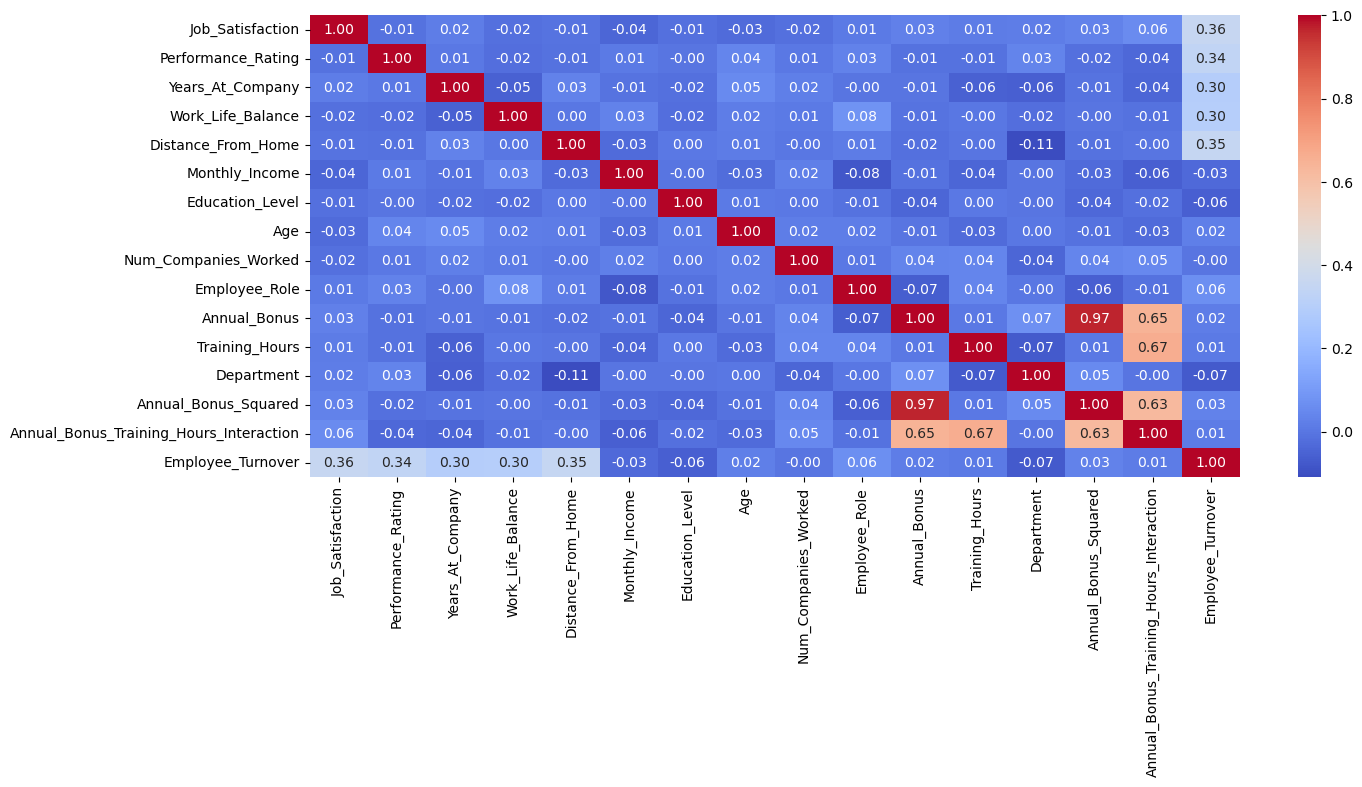

In [111]:
plt.figure(figsize=(15,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [112]:
df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

### Relation of each feature with the label(output)

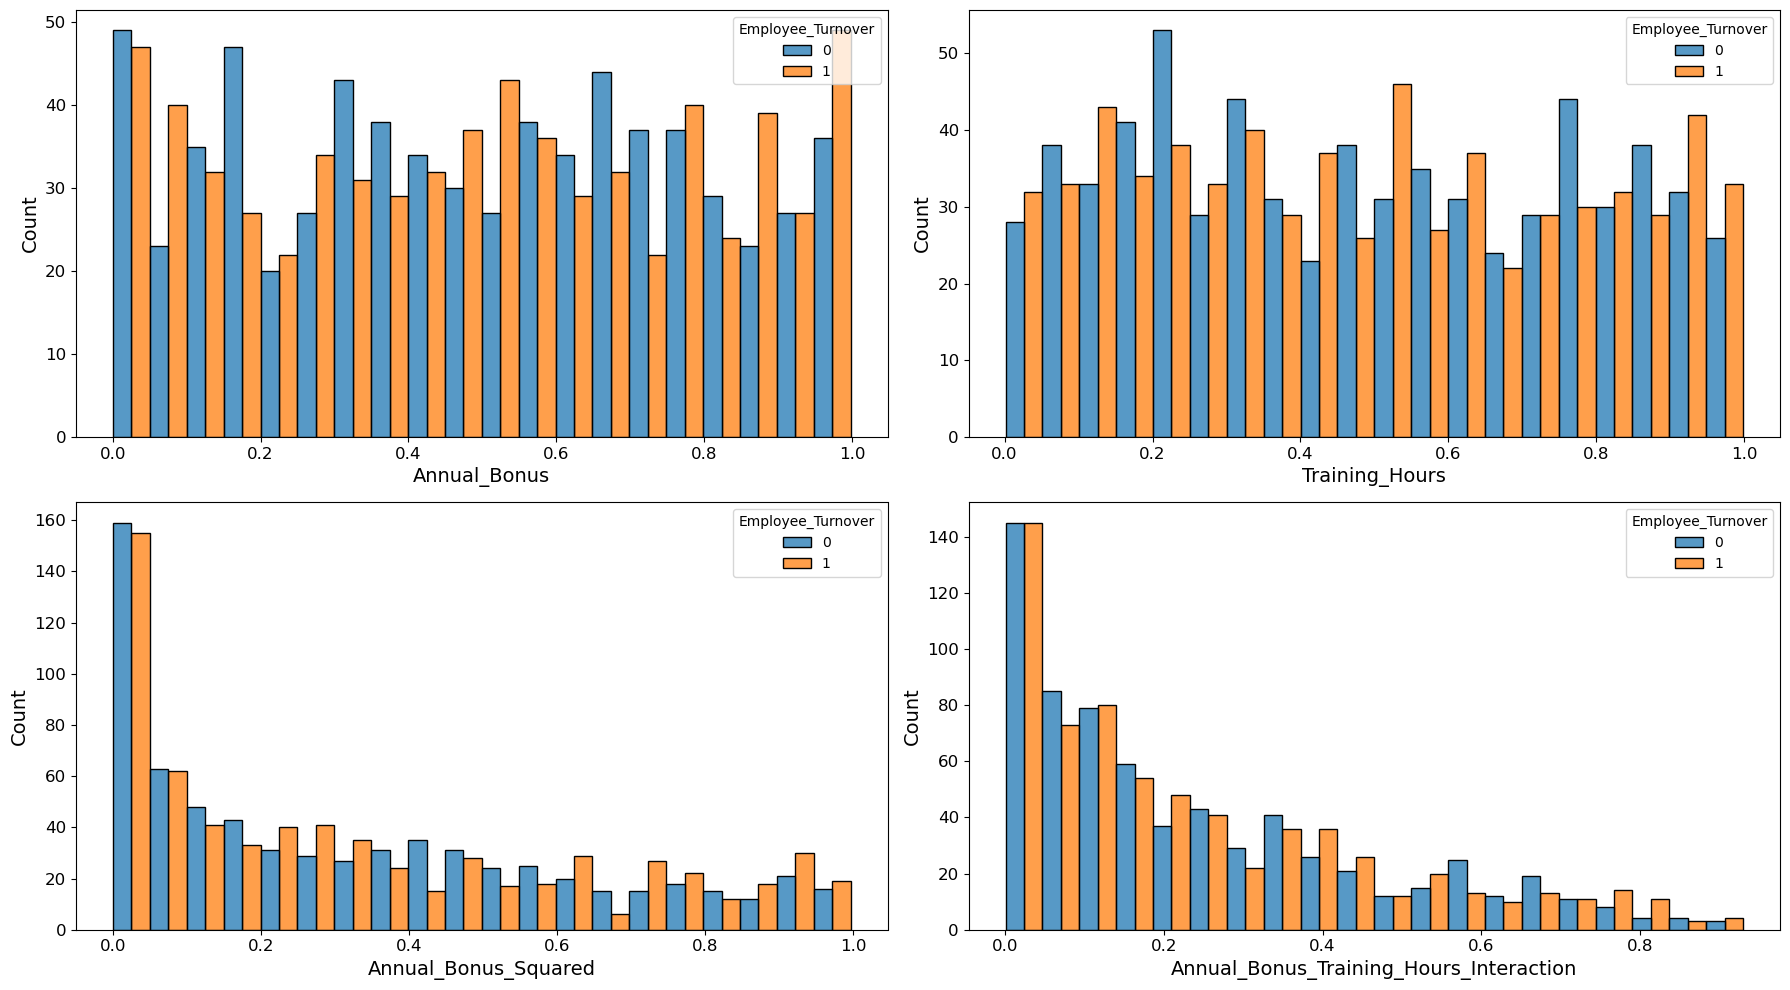

In [113]:
fig,axes=plt.subplots(2,2,figsize=(18,10))

sns.histplot(ax=axes[0,0],data=df,x="Annual_Bonus",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[0,1],data=df,x="Training_Hours",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,0],data=df,x="Annual_Bonus_Squared",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,1],data=df,x="Annual_Bonus_Training_Hours_Interaction",hue="Employee_Turnover",bins=20,multiple="dodge")

for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    
plt.tight_layout()

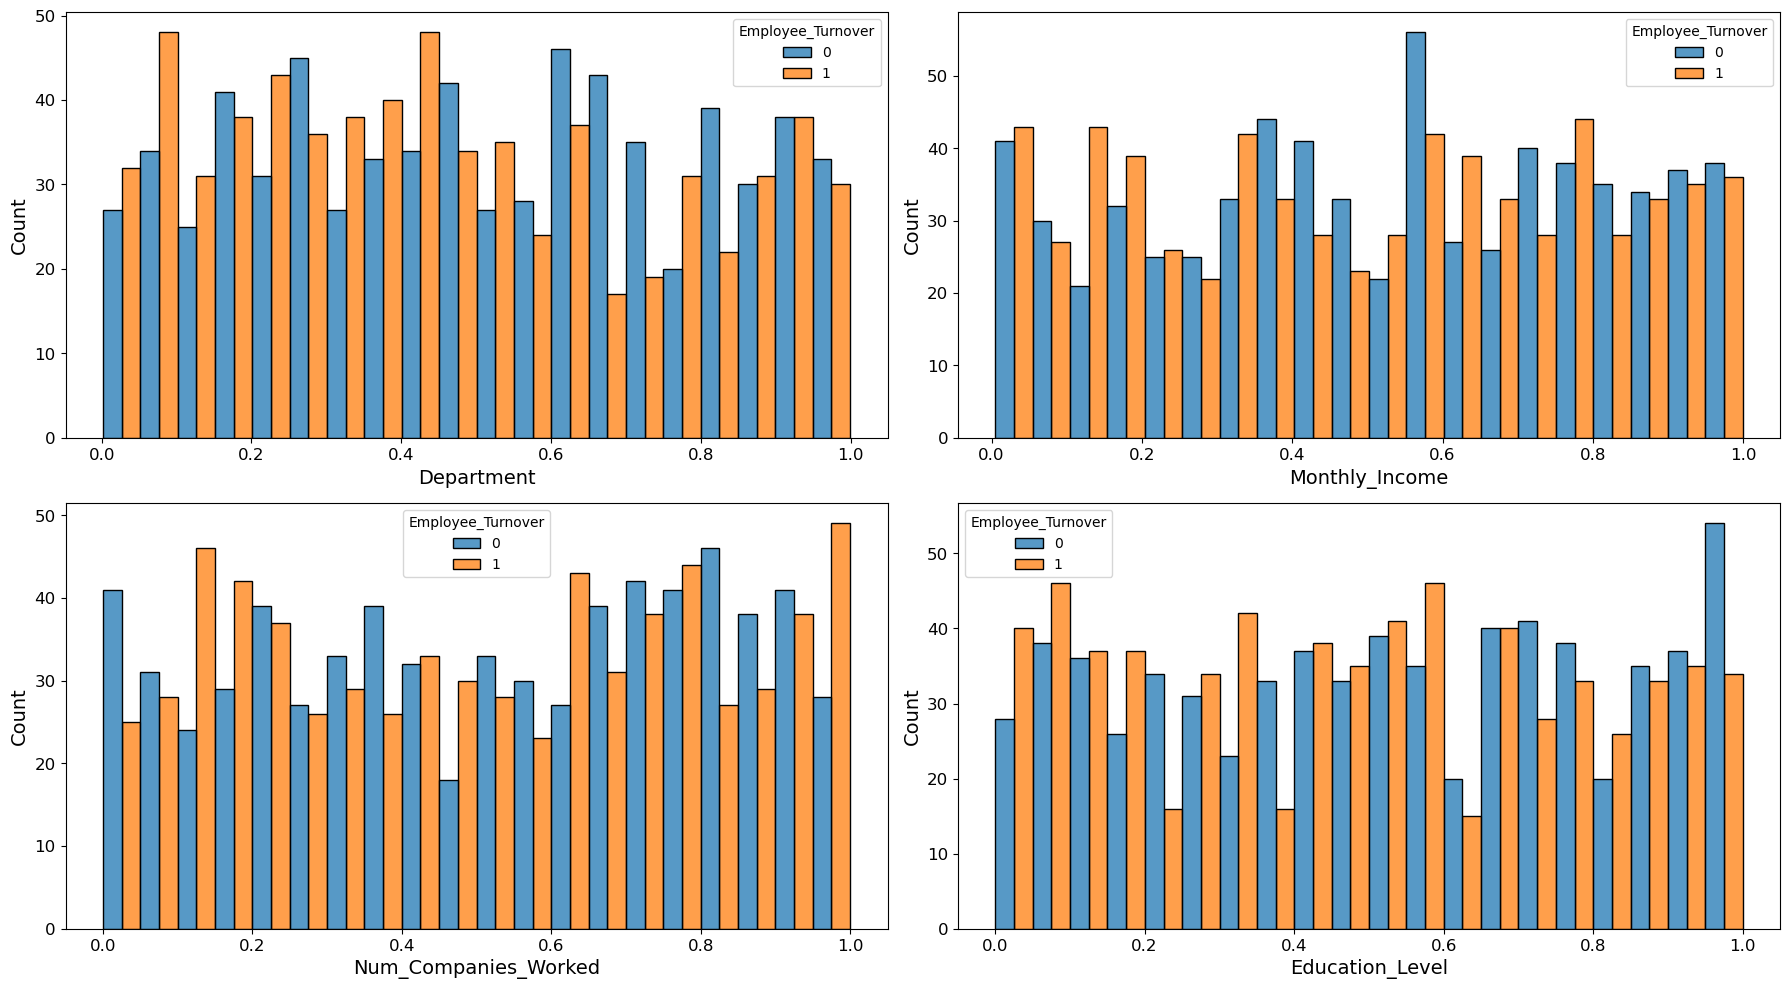

In [114]:
fig,axes=plt.subplots(2,2,figsize=(18,10))

sns.histplot(ax=axes[0,0],data=df,x="Department",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[0,1],data=df,x="Monthly_Income",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,0],data=df,x="Num_Companies_Worked",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,1],data=df,x="Education_Level",hue="Employee_Turnover",bins=20,multiple="dodge")

for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(),fontsize=14)
    ax.set_ylabel(ax.get_ylabel(),fontsize=14)
    ax.tick_params(axis="both",labelsize=12)

plt.tight_layout()

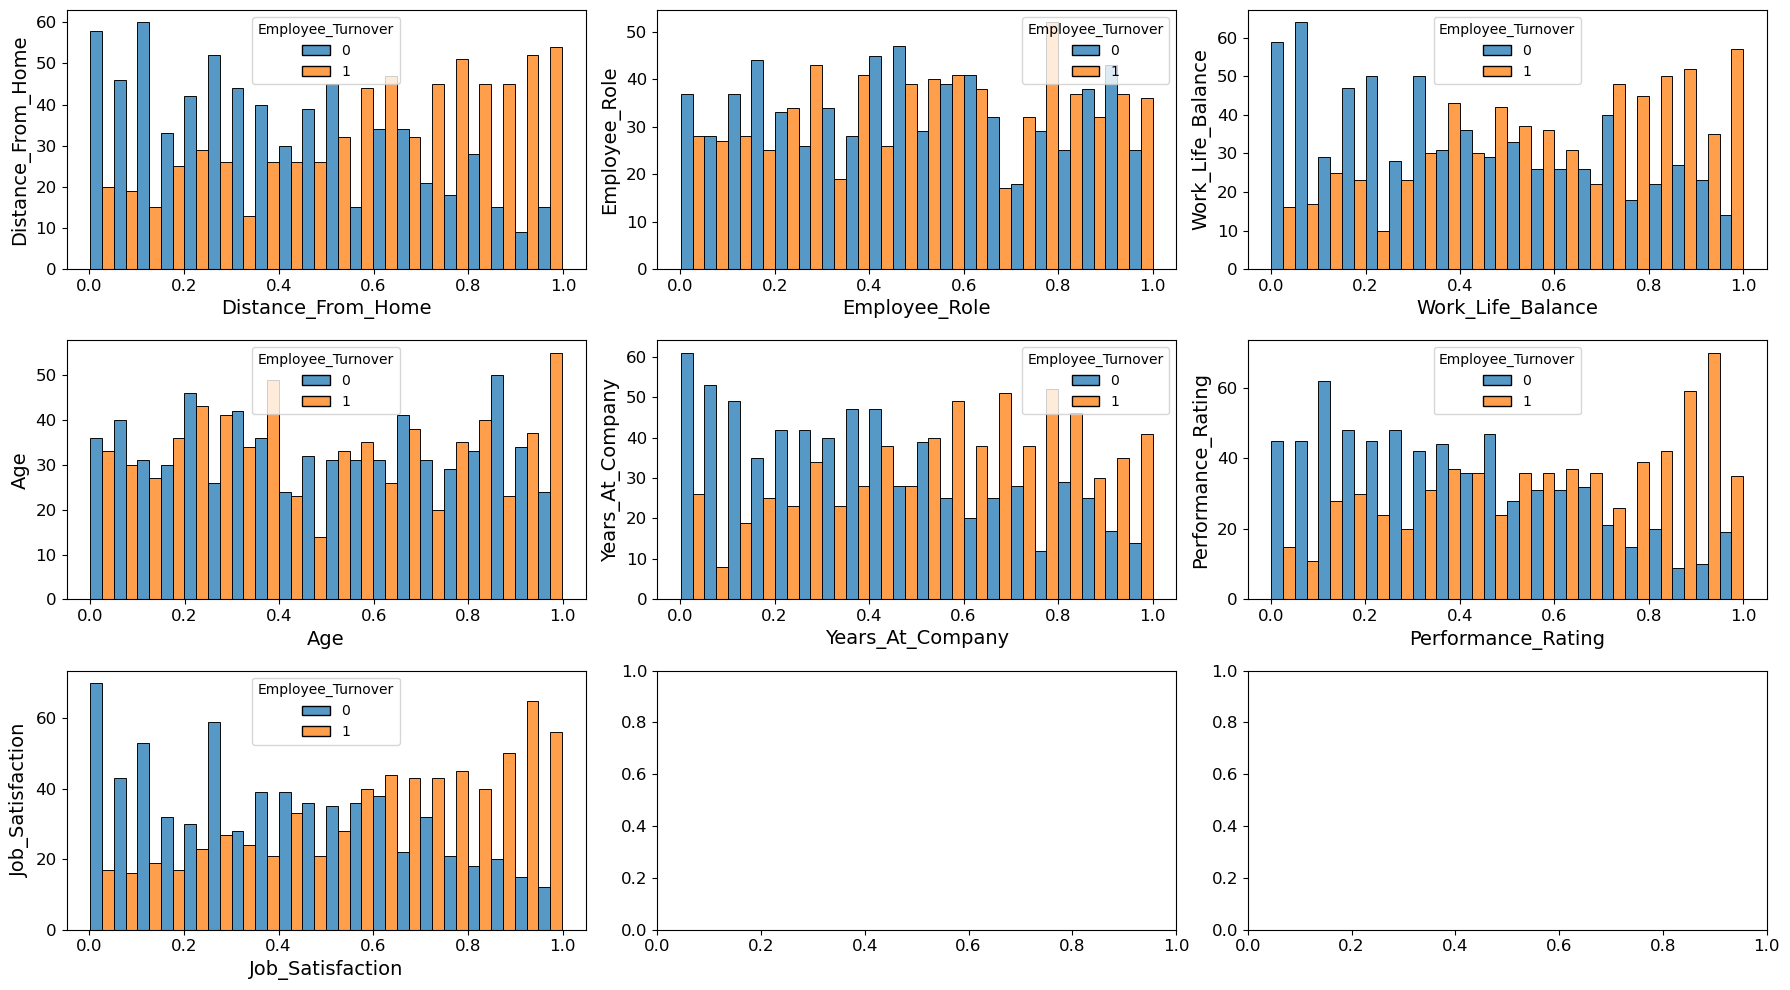

In [115]:
fig,axes=plt.subplots(3,3,figsize=(18,10))

sns.histplot(ax=axes[0,0],data=df,x="Distance_From_Home",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[0,1],data=df,x="Employee_Role",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[0,2],data=df,x="Work_Life_Balance",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,0],data=df,x="Age",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,1],data=df,x="Years_At_Company",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[1,2],data=df,x="Performance_Rating",hue="Employee_Turnover",bins=20,multiple="dodge")
sns.histplot(ax=axes[2,0],data=df,x="Job_Satisfaction",hue="Employee_Turnover",bins=20,multiple="dodge")

for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(),fontsize=14)
    ax.set_ylabel(ax.get_xlabel(),fontsize=14)
    ax.tick_params(axis="both",labelsize=12)

plt.tight_layout()

### Outlier Detection

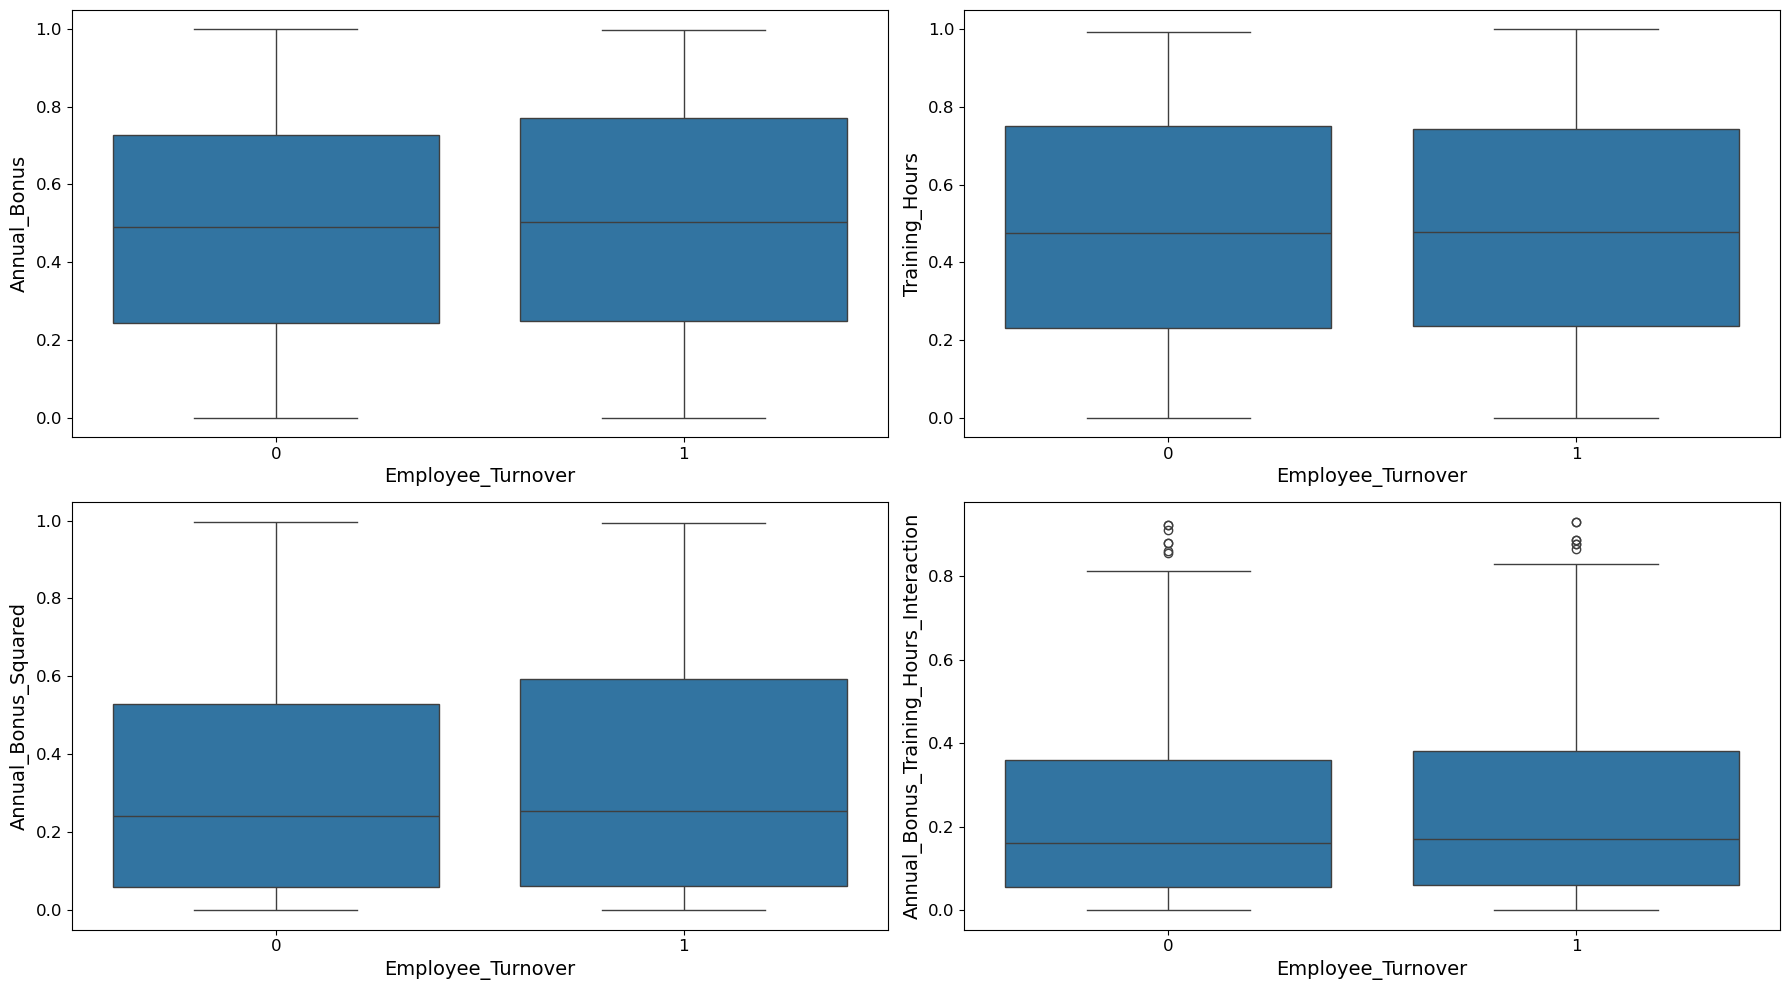

In [116]:
fig,axes=plt.subplots(2,2,figsize=(18,10))

sns.boxplot(ax=axes[0,0],data=df,x="Employee_Turnover",y="Annual_Bonus")
sns.boxplot(ax=axes[0,1],data=df,x="Employee_Turnover",y="Training_Hours")
sns.boxplot(ax=axes[1,0],data=df,x="Employee_Turnover",y="Annual_Bonus_Squared")
sns.boxplot(ax=axes[1,1],data=df,x="Employee_Turnover",y="Annual_Bonus_Training_Hours_Interaction")


for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(),fontsize=14)
    ax.set_ylabel(ax.get_ylabel(),fontsize=14)
    ax.tick_params(axis="both",labelsize=12)

plt.tight_layout()

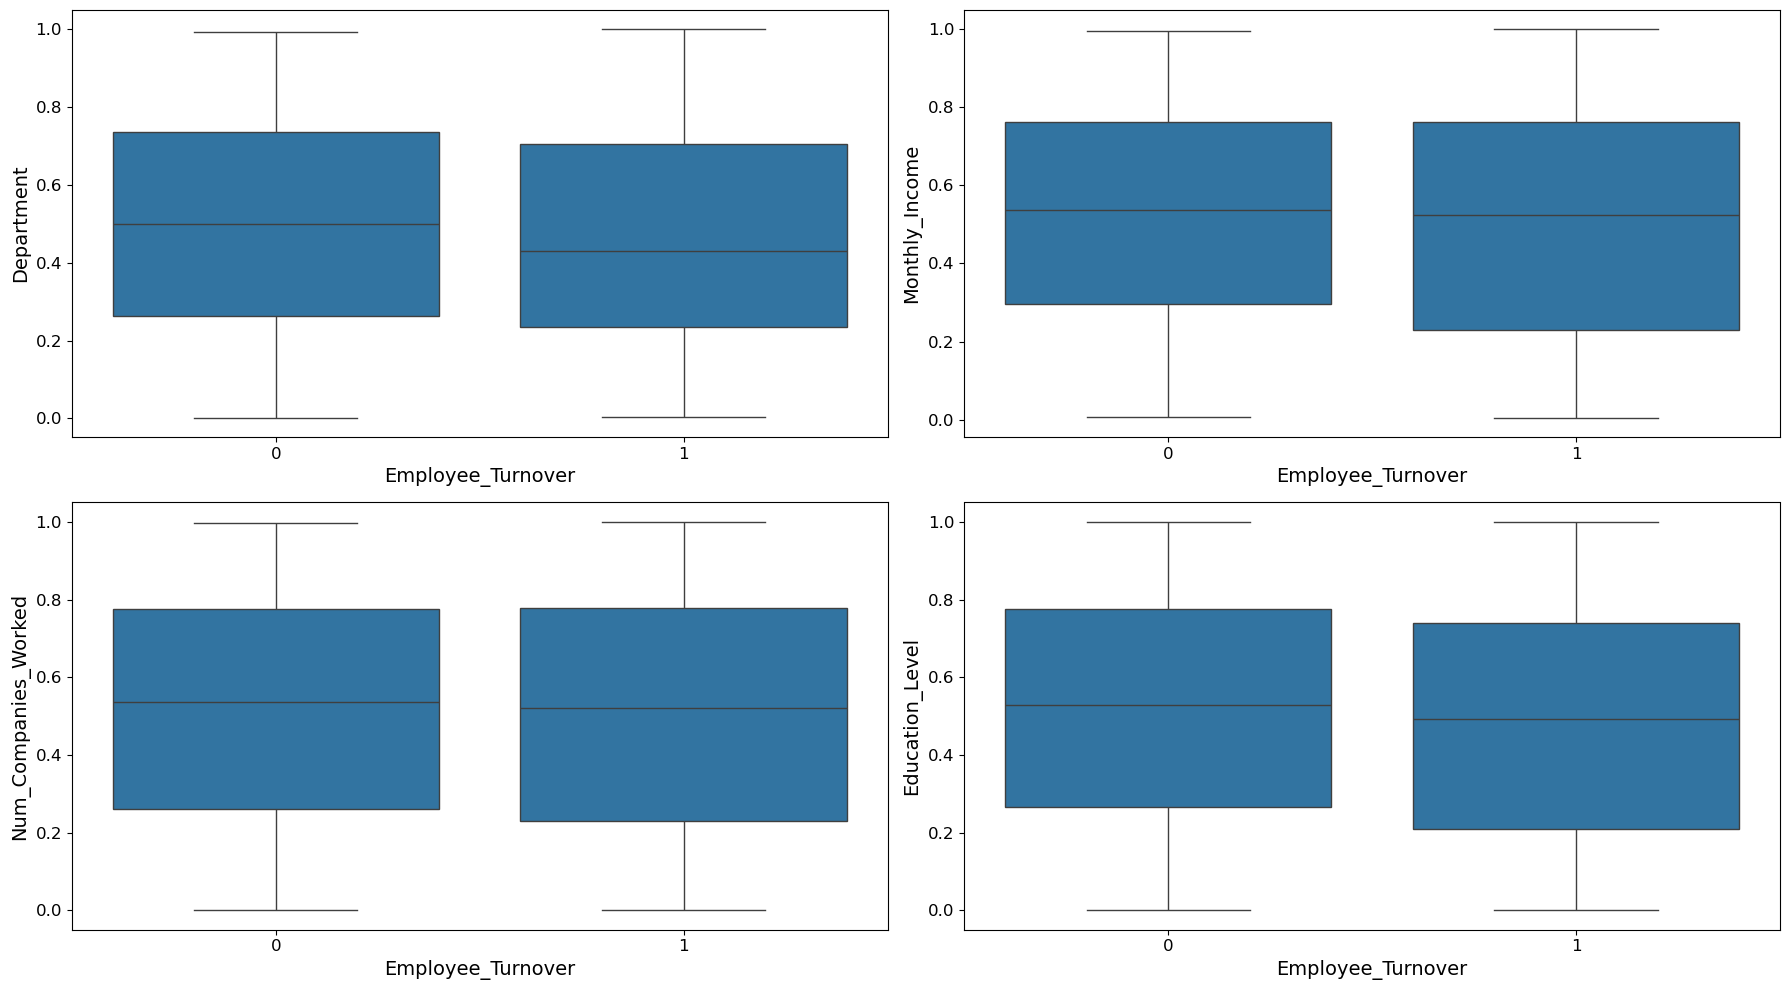

In [117]:
fig,axes=plt.subplots(2,2,figsize=(18,10))

sns.boxplot(ax=axes[0,0],data=df,x="Employee_Turnover",y="Department")
sns.boxplot(ax=axes[0,1],data=df,x="Employee_Turnover",y="Monthly_Income")
sns.boxplot(ax=axes[1,0],data=df,x="Employee_Turnover",y="Num_Companies_Worked")
sns.boxplot(ax=axes[1,1],data=df,x="Employee_Turnover",y="Education_Level")


for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(),fontsize=14)
    ax.set_ylabel(ax.get_ylabel(),fontsize=14)
    ax.tick_params(axis="both",labelsize=12)

plt.tight_layout()

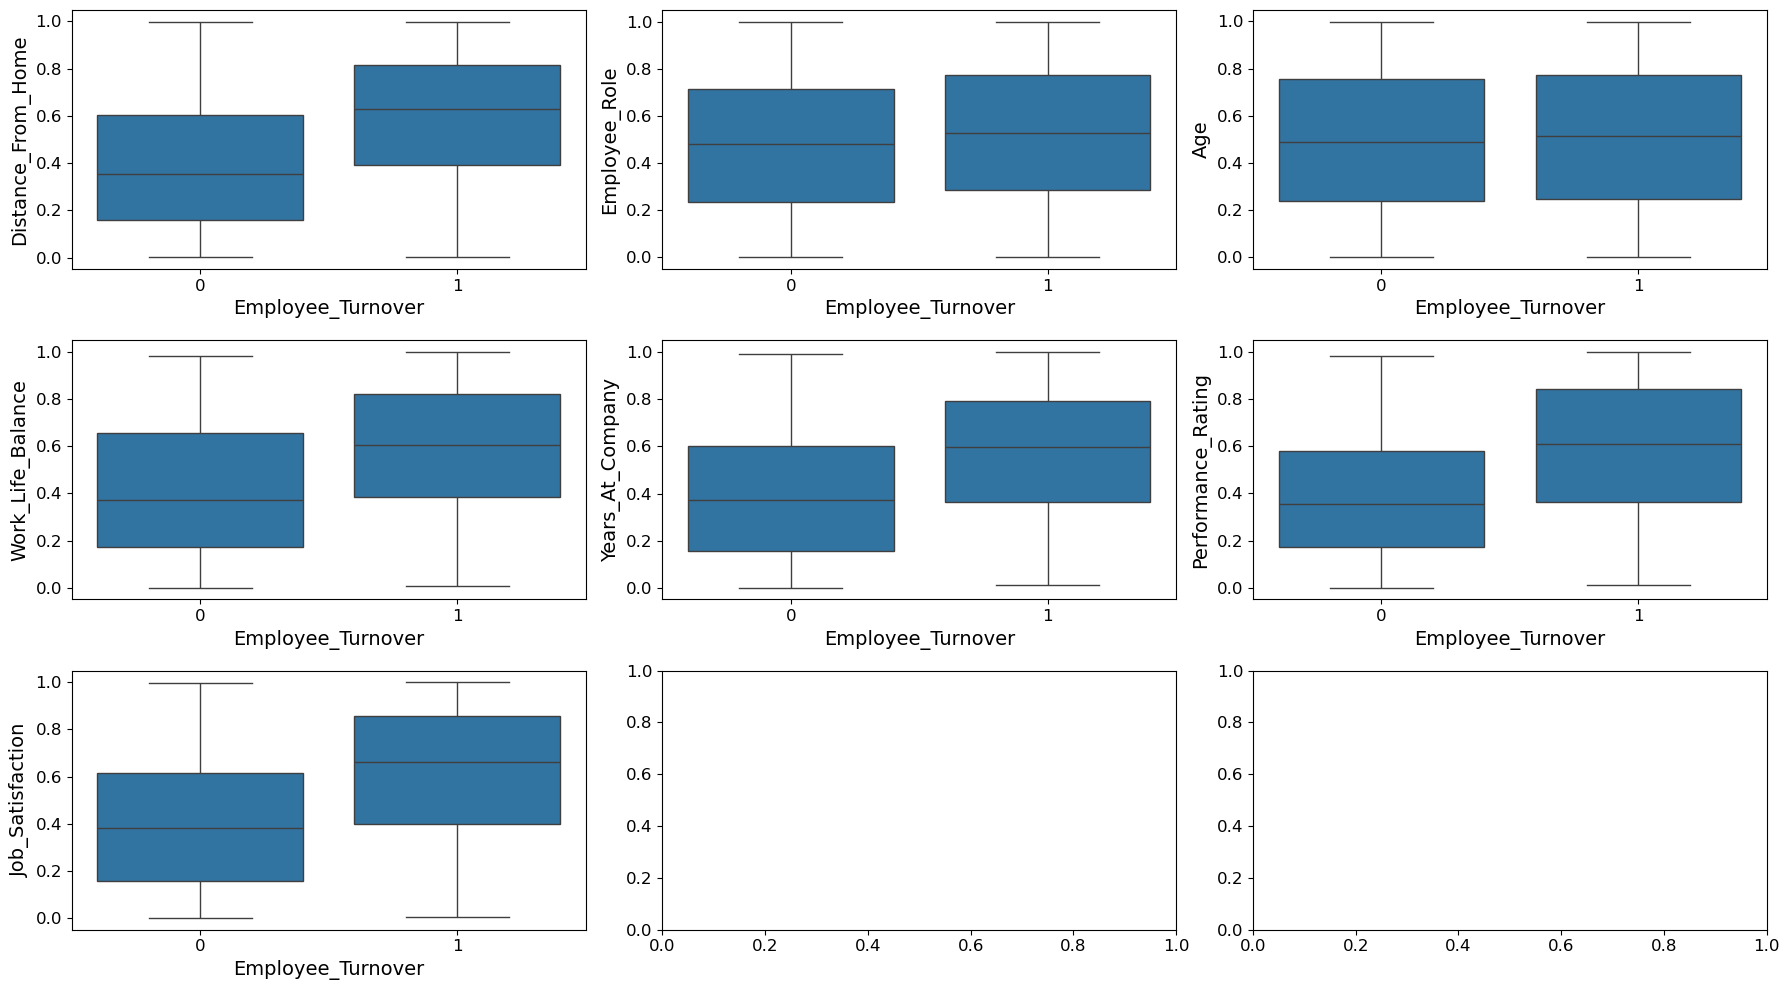

In [118]:
fig,axes=plt.subplots(3,3,figsize=(18,10))

sns.boxplot(ax=axes[0,0],data=df,x="Employee_Turnover",y="Distance_From_Home")
sns.boxplot(ax=axes[0,1],data=df,x="Employee_Turnover",y="Employee_Role")
sns.boxplot(ax=axes[0,2],data=df,x="Employee_Turnover",y="Age")
sns.boxplot(ax=axes[1,0],data=df,x="Employee_Turnover",y="Work_Life_Balance")
sns.boxplot(ax=axes[1,1],data=df,x="Employee_Turnover",y="Years_At_Company")
sns.boxplot(ax=axes[1,2],data=df,x="Employee_Turnover",y="Performance_Rating")
sns.boxplot(ax=axes[2,0],data=df,x="Employee_Turnover",y="Job_Satisfaction")


for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(),fontsize=14)
    ax.set_ylabel(ax.get_ylabel(),fontsize=14)
    ax.tick_params(axis="both",labelsize=12)

plt.tight_layout()

## Train-Test-Split

### Using Logistic Regression as a Base Model

In [119]:
X=df.drop(columns="Employee_Turnover")
y=df["Employee_Turnover"]

In [120]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

In [121]:
lr=LogisticRegression(max_iter=200)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [122]:
#L1 Regularization
lasso=LogisticRegression(penalty='l1',solver='liblinear',C=0.5)
lasso.fit(X_train,y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [123]:
#L2 Regularization
ridge=LogisticRegression(penalty='l2',C=1,max_iter=200)
ridge.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [124]:
#Evaluation
models={"Baseline":lr,"Lasso":lasso,"Ridge":ridge}

for name,model in models.items():
    y_pred=model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))


Baseline
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Lasso
Accuracy: 0.8703703703703703
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       145
           1       0.88      0.83      0.86       125

    accuracy                           0.87       270
   macro avg       0.87      0.87      0.87       270
weighted avg       0.87      0.87      0.87       270


Ridge
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg     